In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from sklearn.svm import LinearSVC

import genSyntheticData as gsd
import plotData as pd

from matplotlib import pyplot as plt
import time

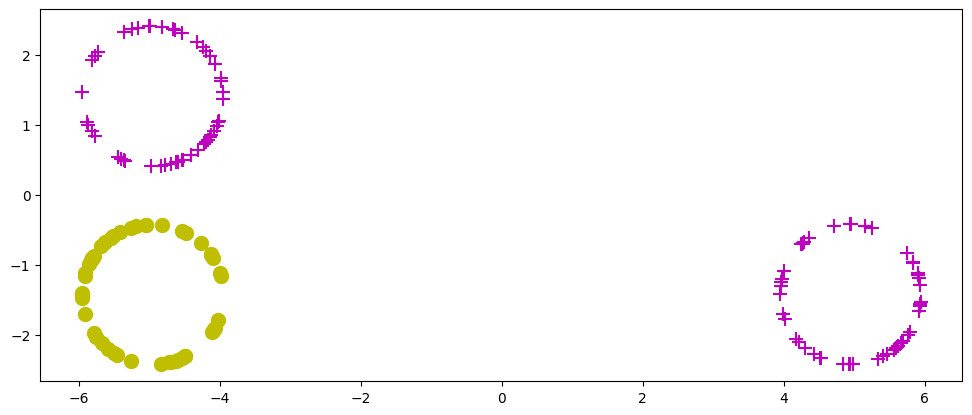

In [3]:
# The genChallengeData function takes two arguments
# level should be a non-negative number strictly greater than zero
# n should be a non-negative integer as it decides the number of points
myLevel = 0.2
XPos, yPos, XNeg, yNeg = gsd.genChallengeData( level = myLevel, n = 50 )

X = np.vstack( (XPos, XNeg) )
y = np.concatenate( (yPos, yNeg) )

fig = pd.getFigure( 2 * np.sqrt( 2 ) * ( 1 + 1 / ( 2 * myLevel ) ) + 2, 2 * np.sqrt( 2 ) + 2 )
pd.plot2D( XPos, fig, color = 'm', marker = '+' )
pd.plot2D( XNeg, fig, color = 'y', marker = 'o' )
plt.show()

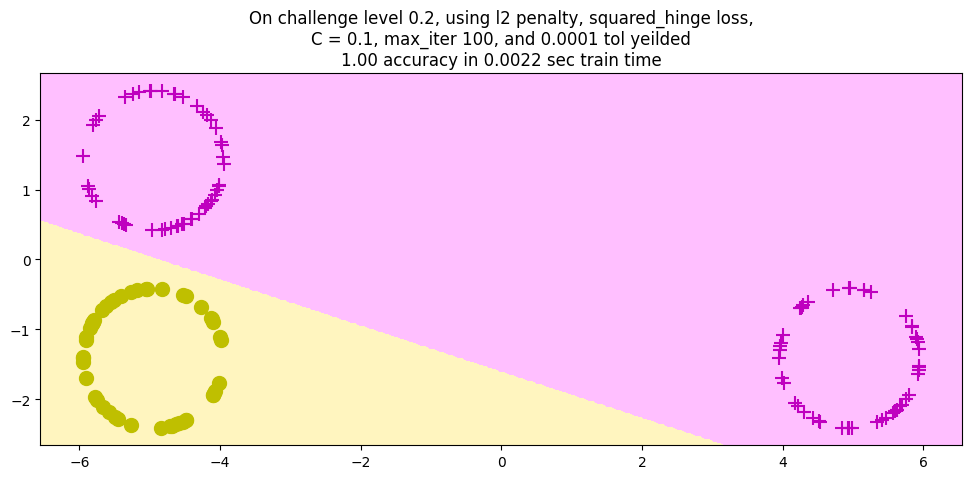

In [4]:
myPenalty = "l2"
myC = 0.1
myLoss = "squared_hinge"
myMaxIter = 100
myTol = 1e-4
clf = LinearSVC( penalty = myPenalty, loss = myLoss, C = myC, tol = myTol, max_iter = myMaxIter )

n_runs = 5
t_train = 0
for t in range( n_runs ):
    tic = time.perf_counter()
    clf.fit( X, y )
    toc = time.perf_counter()
    t_train += toc - tic
t_train /= n_runs

acc = np.average( y == clf.predict( X ) )

w = clf.coef_.reshape(-1)
b = clf.intercept_

mySVM = lambda X: X.dot(w) + b

fig3 = pd.getFigure( 2 * np.sqrt( 2 ) * ( 1 + 1 / ( 2 * myLevel ) ) + 2, 2 * np.sqrt( 2 ) + 2 )
pd.shade2D( mySVM, fig3, mode = 'batch', xlim = np.max( np.abs( X[ :, 0 ] ) ) * 1.1, ylim = np.max( np.abs( X[ :, 1 ] ) ) * 1.1 )
pd.plot2D( XPos, fig3, color = 'm', marker = '+' )
pd.plot2D( XNeg, fig3, color = 'y', marker = 'o' )
plt.title( f"On challenge level {myLevel}, using {myPenalty} penalty, {myLoss} loss,\nC = {myC}, max_iter {myMaxIter}, and {myTol} tol yeilded\n{acc:.2f} accuracy in {t_train:.4f} sec train time" )
plt.show()